In [3]:
import os
import sys
import importlib

# 1. Faster Workspace Setup
%cd /content
if not os.path.exists("TripoSR"):
    !git clone --depth 1 https://github.com/VAST-AI-Research/TripoSR.git
%cd /content/TripoSR
sys.path.append('/content/TripoSR') # Ensure TripoSR is in path for imports

# 2. Combined Optimized Installation
print("[*] Rapid environment setup... (Est. 2 mins)")
!pip install --no-cache-dir \
    "numpy==1.26.4" \
    "transformers==4.35.0" \
    "huggingface-hub==0.17.3" \
    "tokenizers>=0.14,<0.15" \
    "torchao>=0.16.0" \
    "omegaconf==2.3.0" \
    "einops==0.7.0" \
    "trimesh==4.0.5" \
    "xatlas==0.0.9" \
    "moderngl==5.10.0" \
    "rembg" "onnxruntime" \
    "diffusers==0.23.1" "accelerate==0.24.1" \
    "peft==0.6.2" \
    "cupy-cuda12x" \
    "scikit-build-core"

# 3. Build torchmcubes only if missing
if importlib.util.find_spec("torchmcubes") is None:
    print("[*] Building torchmcubes...")
    !pip install --no-cache-dir git+https://github.com/tatsy/torchmcubes.git

# 4. Final Verification
import numpy, torch
print(f"\n--- STATUS ---\nNumPy: {numpy.__version__}\nCUDA: {torch.cuda.is_available()}")

if not numpy.__version__.startswith('1.26'):
    print("\n[!] Restarting runtime to finish setup...")
    os.kill(os.getpid(), 9)

/content
/content/TripoSR
[*] Rapid environment setup... (Est. 2 mins)

--- STATUS ---
NumPy: 1.26.4
CUDA: True


In [4]:
print("hello")

hello


In [5]:
import sys
import time
import torch
import numpy as np
from PIL import Image
from diffusers import StableDiffusionPipeline, LCMScheduler
from tsr.utils import remove_background, resize_foreground
import rembg
from IPython.display import display as ipy_display

# sys.path.append('/content/TripoSR') # Moved to setup cell
from tsr.system import TSR

class TrellisDraftPipeline:
    def __init__(self):
        self.device = "cuda" if torch.cuda.is_available() else "cpu"
        self.precision = torch.float16
        print(f"[*] Initializing ML Pipeline on: {self.device.upper()}")

        self.rembg_session = rembg.new_session("isnet-general-use", providers=['CPUExecutionProvider'])

        self.sd_pipe = StableDiffusionPipeline.from_pretrained(
            "runwayml/stable-diffusion-v1-5",
            torch_dtype=self.precision,
            safety_checker=None
        ).to(self.device)
        self.sd_pipe.load_lora_weights("latent-consistency/lcm-lora-sdv1-5")
        self.sd_pipe.scheduler = LCMScheduler.from_config(self.sd_pipe.scheduler.config)

        self.trellis = TSR.from_pretrained(
            "stabilityai/TripoSR",
            config_name="config.yaml",
            weight_name="model.ckpt"
        ).to(self.device)

        self.trellis.renderer.chunk_size = 8192
        print("[+] Pipeline Ready.")

    def _score_image(self, img):
        """Returns (passes: bool, reason: str). Fast quality gate before sending to Trellis."""
        rgba = rembg.remove(img, session=self.rembg_session)
        alpha = np.array(rgba)[:, :, 3]
        fg_ratio = (alpha > 128).sum() / alpha.size

        if fg_ratio < 0.10:
            return False, f"foreground too small ({fg_ratio:.2%}) — likely partial object"
        if fg_ratio > 0.75:
            return False, f"foreground too large ({fg_ratio:.2%}) — background not clean"

        ys, xs = np.where(alpha > 128)
        if len(xs) == 0:
            return False, "no foreground detected"
        cx = xs.mean() / alpha.shape[1]
        cy = ys.mean() / alpha.shape[0]
        if not (0.25 < cx < 0.75 and 0.2 < cy < 0.8):
            return False, f"object off-center (cx={cx:.2f}, cy={cy:.2f})"

        return True, "ok"

    def generate_draft(self, prompt: str, output_path: str = "model.glb", max_tries: int = 4):
        start_time = time.time()
        print(f"[*] Starting generation for prompt: '{prompt}'")

        with torch.no_grad():
            # Step 1: Generate image with retry loop
            self.sd_pipe.to(self.device)
            full_prompt = f"full body {prompt}, single object, product shot, plain white background, centered, complete object visible, no cropping, high detail"
            negative_prompt = "cropped, partial, close-up, portrait, face only, cut off, multiple objects, gradient background, vignette, textured background, busy background, dark background, blurry, low quality, out of frame"

            raw_image = None
            for attempt in range(max_tries):
                print(f"[-] 1/3: Generating 2D Concept (attempt {attempt + 1}/{max_tries})...")
                candidate = self.sd_pipe(
                    prompt=full_prompt,
                    negative_prompt=negative_prompt,
                    num_inference_steps=8,
                    guidance_scale=2.0,
                ).images[0]

                passes, reason = self._score_image(candidate)
                print(f"    → {'✓' if passes else '✗'} {reason}")
                ipy_display(candidate.resize((256, 256)))

                if passes:
                    raw_image = candidate
                    break

            if raw_image is None:
                print(f"[!] All {max_tries} attempts failed quality check, using last attempt as fallback")
                raw_image = candidate

            # self.sd_pipe.to("cpu") # Removed: keep on GPU for float16
            torch.cuda.empty_cache()

            # Step 2: Remove background (official TripoSR preprocessing)
            print("[-] 2/3: Removing Background & Normalizing...")
            input_image = remove_background(raw_image, self.rembg_session)
            input_image = resize_foreground(input_image, 0.85)

            image_arr = np.array(input_image).astype(np.float32) / 255.0
            image_arr = image_arr[:, :, :3] * image_arr[:, :, 3:4] + (1 - image_arr[:, :, 3:4]) * 0.5
            input_image = Image.fromarray((image_arr * 255.0).astype(np.uint8))

            print("[DEBUG] Preprocessed Image:")
            ipy_display(input_image.resize((256, 256)))

            # Step 3: Reconstruct
            print("[-] 3/3: Reconstructing 3D Mesh...")
            self.trellis.to(self.device)

            scene_codes = self.trellis(input_image, device=self.device)
            meshes = self.trellis.extract_mesh(scene_codes, resolution=128, has_vertex_color=True)
            meshes[0].export(output_path)

            # self.trellis.to("cpu") # Removed: keep on GPU for consistency or manage explicitly
            torch.cuda.empty_cache()

        print(f"[+] Success! Saved to {output_path} in {time.time() - start_time:.2f}s")
        return output_path

In [6]:
object1 = TrellisDraftPipeline()

[*] Initializing ML Pipeline on: CUDA


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/diffusers/utils/outputs.py:63: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  torch.utils._pytree._register_pytree_node(
You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


[+] Pipeline Ready.


[*] Starting generation for prompt: 'a car'
[-] 1/3: Generating 2D Concept (attempt 1/4)...


  0%|          | 0/8 [00:00<?, ?it/s]

    → ✓ ok


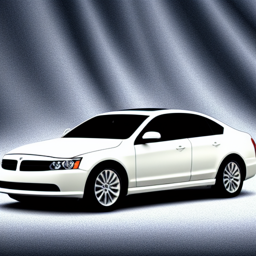

[-] 2/3: Removing Background & Normalizing...
[DEBUG] Preprocessed Image:


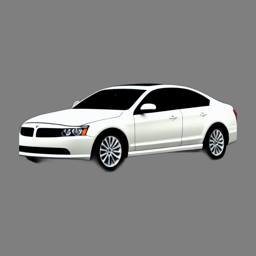

[-] 3/3: Reconstructing 3D Mesh...
[+] Success! Saved to model.glb in 13.20s


'model.glb'

In [7]:
object1.generate_draft("a car")

In [8]:
import base64
import trimesh
from IPython.display import HTML, display

def visualize_and_fix_display(file_path='model.glb'):
    print(f"[*] Checking {file_path}...")

    try:
        # 1. Confirm file validity and print stats
        scene = trimesh.load(file_path)
        if isinstance(scene, trimesh.Scene):
            geometry = next(iter(scene.geometry.values()))
        else:
            geometry = scene

        print(f"[+] File exists. Vertices: {len(geometry.vertices)}, Faces: {len(geometry.faces)}")

        # 2. Create an immediate download link as a fallback
        with open(file_path, "rb") as f:
            b64 = base64.b64encode(f.read()).decode()

        download_html = f'''
        <div style="background-color: #e8f0fe; padding: 15px; border-radius: 8px; border: 1px solid #4285f4; margin-bottom: 20px;">
            <h3 style="margin-top:0; color: #1967d2;">Download Model</h3>
            <p>If the viewer below is blank, click the link to view the file on your local machine:</p>
            <a href="data:application/octet-stream;base64,{b64}"
               download="{file_path}"
               style="background-color: #1a73e8; color: white; padding: 10px 20px; text-decoration: none; border-radius: 4px; font-weight: bold;">
               Download {file_path}
            </a>
        </div>
        '''
        display(HTML(download_html))

        # 3. Enhanced Model Viewer with white background and different lighting
        data_url = f"data:model/gltf-binary;base64,{b64}"
        viewer_html = f"""
        <script type="module" src="https://ajax.googleapis.com/ajax/libs/model-viewer/3.3.0/model-viewer.min.js"></script>
        <div style="width: 100%; height: 500px; border: 1px solid #ccc; background-color: #ffffff;">
            <model-viewer src="{data_url}"
                          style="width: 100%; height: 100%;"
                          auto-rotate
                          camera-controls
                          exposure="1.0"
                          environment-image="neutral"
                          shadow-intensity="1">
            </model-viewer>
        </div>
        """
        display(HTML(viewer_html))

    except Exception as e:
        print(f"[!] Error processing model: {str(e)}")

visualize_and_fix_display('model.glb')

[*] Checking model.glb...
[+] File exists. Vertices: 9953, Faces: 19818
